In [1]:
!pip install -q pandas matplotlib seaborn nltk wordcloud

In [16]:
!apt-get install -y fonts-noto

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-noto is already the newest version (20201225-1build1).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.


In [39]:
!apt-get install -y fonts-noto fonts-noto-cjk fonts-noto-color-emoji

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-noto-cjk is already the newest version (1:20220127+repack1-1).
fonts-noto-cjk set to manually installed.
fonts-noto is already the newest version (20201225-1build1).
fonts-noto-color-emoji is already the newest version (2.047-0ubuntu0.22.04.1).
fonts-noto-color-emoji set to manually installed.
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.


In [40]:
import matplotlib.font_manager as fm
fm._rebuild()

AttributeError: module 'matplotlib.font_manager' has no attribute '_rebuild'

In [46]:
font_path = "/usr/share/fonts/truetype/freefont/FreeSerif.ttf"

In [47]:
!apt-get install -y fonts-freefont-ttf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-freefont-ttf
0 upgraded, 1 newly installed, 0 to remove and 6 not upgraded.
Need to get 2,388 kB of archives.
After this operation, 6,653 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-freefont-ttf all 20120503-10build1 [2,388 kB]
Fetched 2,388 kB in 2s (1,069 kB/s)
Selecting previously unselected package fonts-freefont-ttf.
(Reading database ... 120682 files and directories currently installed.)
Preparing to unpack .../fonts-freefont-ttf_20120503-10build1_all.deb ...
Unpacking fonts-freefont-ttf (20120503-10build1) ...
Setting up fonts-freefont-ttf (20120503-10build1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from collections import Counter
from wordcloud import WordCloud
from matplotlib import font_manager

nltk.download('stopwords')
from nltk.corpus import stopwords

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [48]:
from matplotlib import font_manager

font_path = "/usr/share/fonts/truetype/freefont/FreeSerif.ttf"
prop = font_manager.FontProperties(fname=font_path)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
BASE_PATH = "/content/drive/MyDrive/Research Code and Data/data_processed/"

datasets = {
    "THAR": pd.read_csv(BASE_PATH + "thar_cleaned.csv"),
    "HASOC": pd.read_csv(BASE_PATH + "hasoc_cleaned.csv"),
    "AOLD": pd.read_csv(BASE_PATH + "aold_cleaned.csv"),
    "Combined": pd.read_csv(BASE_PATH + "combined_cleaned.csv")
}

word count distribution

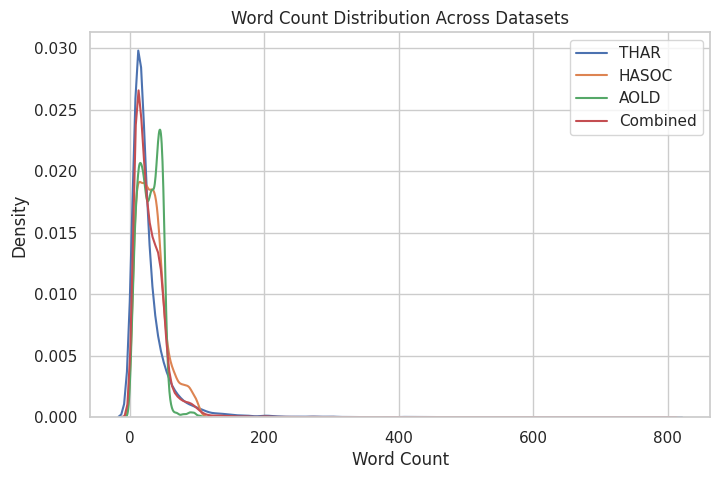


Word Count Summary:


,Dataset,Average Words
0,THAR,29.67
1,HASOC,33.20
2,AOLD,29.98
3,Combined,30.66


In [6]:
def word_count_analysis(datasets):

    summary = []

    plt.figure()

    for name, df in datasets.items():

        df["word_count"] = df["text"].apply(lambda x: len(str(x).split()))

        avg = df["word_count"].mean()

        summary.append({
            "Dataset": name,
            "Average Words": round(avg, 2)
        })

        sns.kdeplot(df["word_count"], label=name)

    plt.title("Word Count Distribution Across Datasets")
    plt.xlabel("Word Count")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

    summary_df = pd.DataFrame(summary)
    print("\nWord Count Summary:")
    display(summary_df)

    return summary_df

word_count_df = word_count_analysis(datasets)

multilingual stopwords

In [31]:
# English stopwords
stop_words = set(stopwords.words('english'))

# Hinglish + functional words
hinglish_stopwords = {
    'hai', 'hain', 'tha', 'thi',
    'ka', 'ki', 'ke',
    'to', 'ye', 'wo',
    'se', 'ko', 'mein', 'me',
    'aur', 'ya', 'kya',
    'bhi', 'koi', 'sab', 'par',
    'liye', 'apne', 'bat', 'log',
    'nhi','nahi','kya','tum','mera','tera','yeh','wo',
    'bhai','acha','haan','kyu','kar','raha'
}

# Dataset noise
dataset_noise_words = {
    'amp', 'wil',
    'one', 'get', 'like'
}

hindi_stop = set([
    "है","और","का","की","के","को","में","पर","से","तक","लिए",
    "यह","वह","जो","कि","था","थे","हैं","भी","नहीं","तो"
])

# Final stopword list
stop_words = stop_words.union(
    hinglish_stopwords,
    dataset_noise_words,
    hindi_stop
)

text cleaning

In [32]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)

    # Keep English + Devanagari
    text = re.sub(r'[^a-zA-Z\u0900-\u097F\s]', '', text)

    tokens = text.split()

    tokens = [
        w for w in tokens
        if w not in stop_words and len(w) > 2
    ]

    return tokens

label-wise text analysis

In [33]:
def get_tokens(text_series):
    words = []

    for text in text_series:
        tokens = clean_text(text)
        words.extend(tokens)

    return words

plot

In [63]:
def plot_top_words(words, title):
    counter = Counter(words)
    most_common = counter.most_common(20)

    words_list = [w[0] for w in most_common]
    counts = [w[1] for w in most_common]

    plt.figure(figsize=(14,6))

    plt.bar(words_list, counts)

    plt.xticks(
        rotation=60,
        ha='right',
        fontproperties=prop
    )

    plt.yticks(fontproperties=prop)

    plt.title(title, fontproperties=prop)
    plt.xlabel("Words", fontproperties=prop)
    plt.ylabel("Frequency", fontproperties=prop)

    plt.tight_layout()
    plt.show()

In [64]:
def get_hate_word_table(df, dataset_name):

    hate_df = df[df['label'] == 1]
    words = get_tokens(hate_df['text'])

    counter = Counter(words)
    most_common = counter.most_common(20)

    freq_df = pd.DataFrame(most_common, columns=["Word", "Frequency"])

    print(f"\n===== {dataset_name} - Hate Word Frequencies =====")
    display(freq_df)

    return freq_df

In [51]:
tables = {}

for name, df in datasets.items():
    tables[name] = get_hate_word_table(df, name)


===== THAR - Hate Word Frequencies =====


,Word,Frequency
0,hindu,1250
1,muslim,862
2,islam,652
3,allah,482
4,aap,394
5,maulana,319
6,dharm,318
7,pakistan,317
8,musalman,315
9,baat,256



===== HASOC - Hate Word Frequencies =====


,Word,Frequency
0,resignpmmodi,350
1,resignmodi,342
2,bengalburning,278
3,people,260
4,india,247
5,fuck,233
6,modikavaccinejumla,188
7,modi,187
8,bitch,187
9,shame,162



===== AOLD - Hate Word Frequencies =====


,Word,Frequency
0,demonetisation,302
1,india,264
2,love,231
3,jihad,227
4,gandhi,225
5,hindu,202
6,people,194
7,muslim,190
8,rape,168
9,golwalkar,167



===== Combined - Hate Word Frequencies =====


,Word,Frequency
0,hindu,1465
1,muslim,1065
2,islam,695
3,india,667
4,allah,494
5,people,460
6,aap,429
7,अपन,378
8,pakistan,370
9,modi,352


In [52]:
for name, table in tables.items():
    table.to_csv(f"{name}_hate_words.csv", index=False)

word cloud

In [65]:
def generate_wordcloud(words, title):

    if len(words) == 0:
        print("No data for WordCloud")
        return

    font_path = "/usr/share/fonts/truetype/freefont/FreeSerif.ttf"

    wc = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        font_path=font_path,
        colormap="viridis",
        max_words=100,
        collocations=False
    ).generate(" ".join(words))

    plt.figure(figsize=(12,6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

run label wise analysis

In [66]:
def label_wise_analysis(df, dataset_name):

    print(f"\n===== {dataset_name} =====")

    hate_df = df[df['label'] == 1]

    hate_words = get_tokens(hate_df['text'])

    plot_top_words(hate_words, f"{dataset_name} - Top Hate Words")
    generate_wordcloud(hate_words, f"{dataset_name} - Hate WordCloud")

fina


===== THAR =====


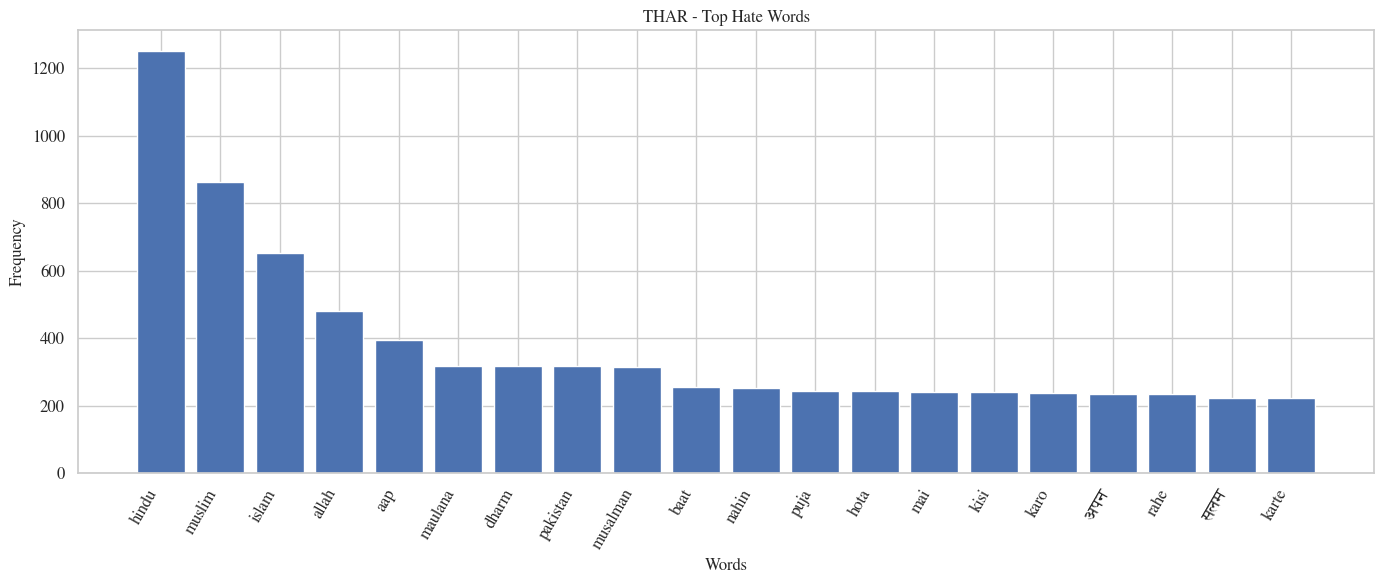

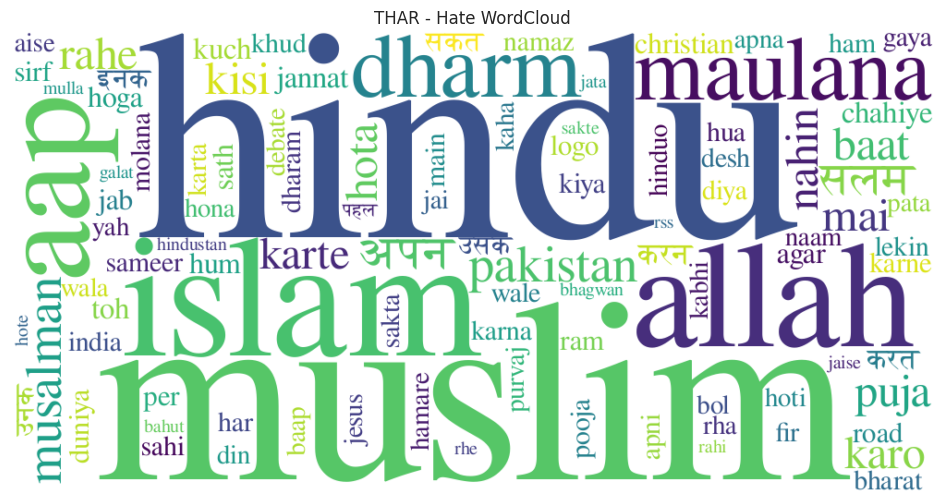


===== HASOC =====


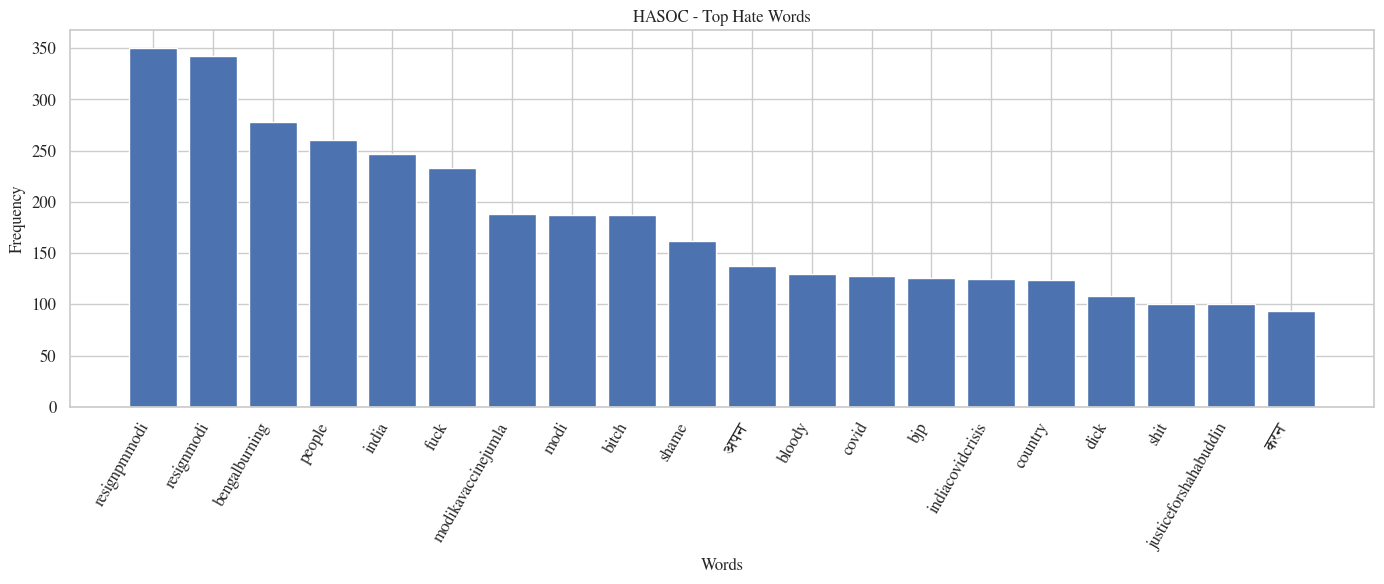

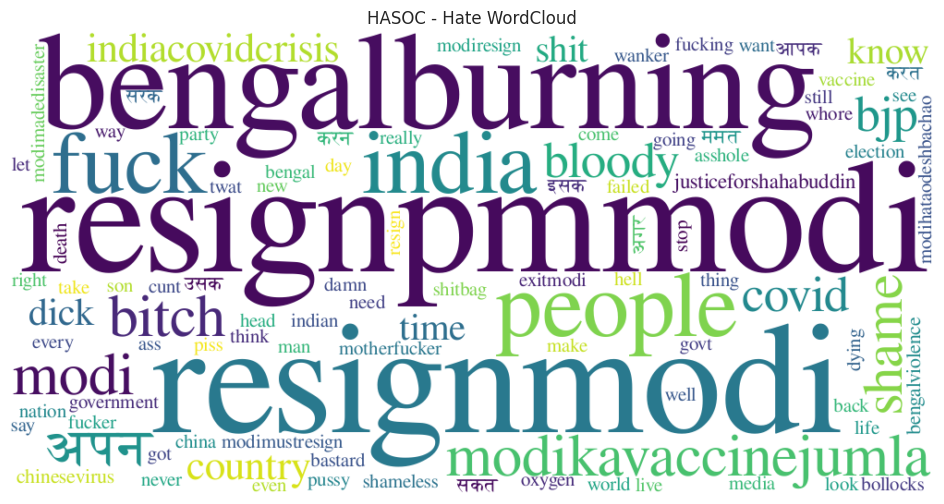


===== AOLD =====


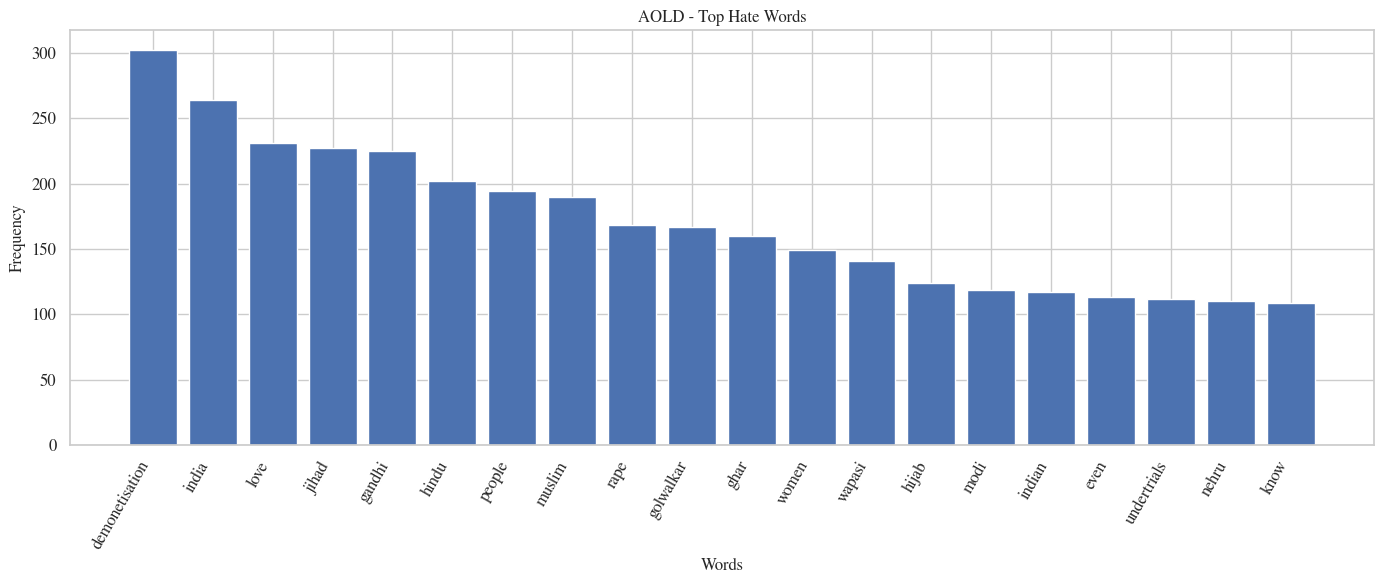

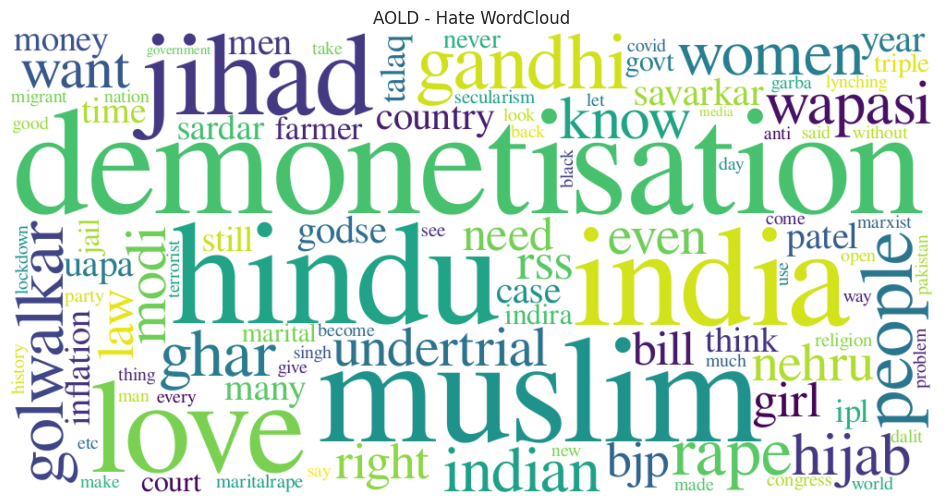


===== Combined =====


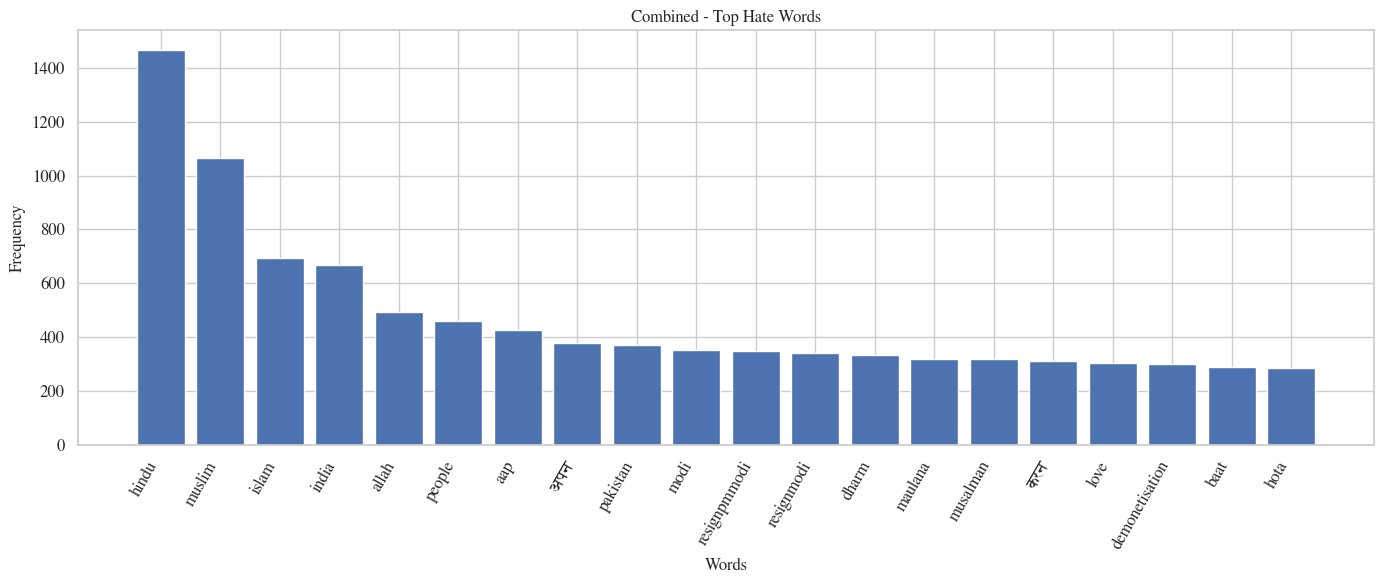

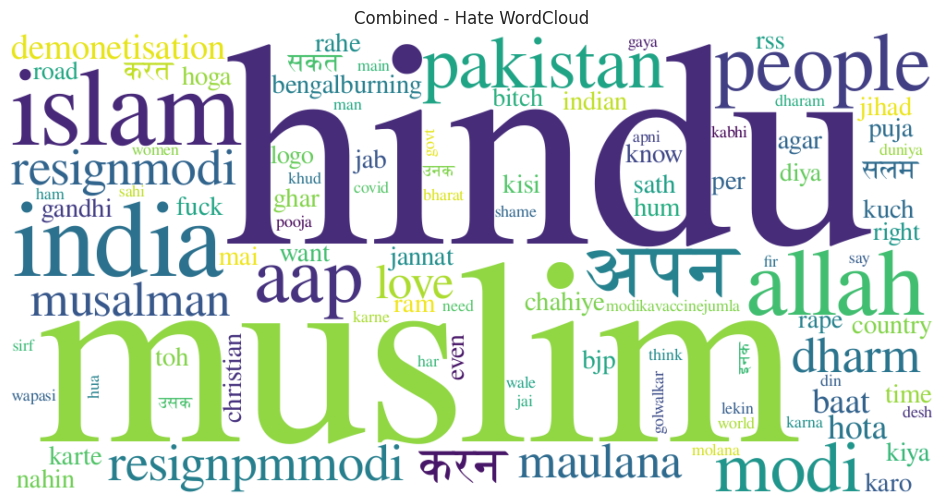

In [67]:
for name, df in datasets.items():
    label_wise_analysis(df, name)

devanagiri analysis


Devanagari Summary:


,Dataset,Count,Percentage
0,THAR,2663,23.06
1,HASOC,3319,49.60
2,AOLD,415,5.15
3,Combined,6397,24.32


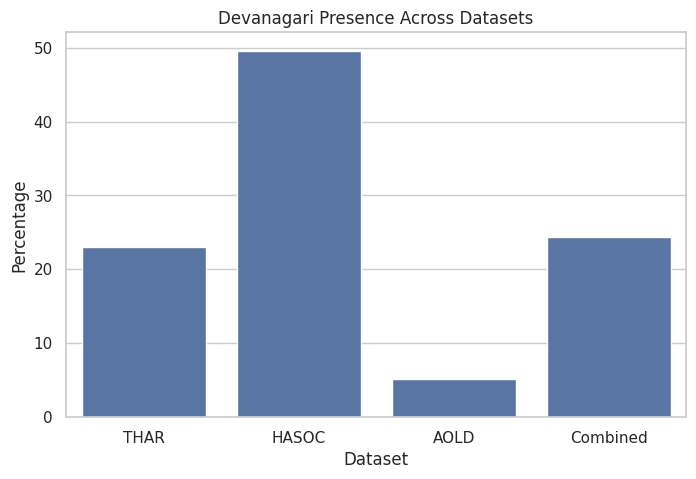

In [13]:
def devanagari_analysis(datasets):

    summary = []

    for name, df in datasets.items():

        df["devanagari"] = df["text"].apply(
            lambda x: bool(re.search(r'[\u0900-\u097F]', str(x)))
        )

        count = df["devanagari"].sum()
        percent = df["devanagari"].mean() * 100

        summary.append({
            "Dataset": name,
            "Count": count,
            "Percentage": round(percent, 2)
        })

    summary_df = pd.DataFrame(summary)

    print("\nDevanagari Summary:")
    display(summary_df)

    plt.figure()
    sns.barplot(data=summary_df, x="Dataset", y="Percentage")
    plt.title("Devanagari Presence Across Datasets")
    plt.ylabel("Percentage")
    plt.show()

    return summary_df

dev_df = devanagari_analysis(datasets)

code-mixing analysis

In [14]:
def is_code_mixed(text):

    text = str(text).lower()

    has_eng = bool(re.search(r'[a-zA-Z]', text))
    has_dev = bool(re.search(r'[\u0900-\u097F]', text))

    tokens = text.split()
    has_hinglish = any(w in hinglish_stop for w in tokens)

    return (has_eng and has_dev) or (has_eng and has_hinglish)

In [15]:
def code_mixing_analysis(datasets):

    summary = []

    for name, df in datasets.items():

        df["code_mixed"] = df["text"].apply(is_code_mixed)

        percent = df["code_mixed"].mean() * 100

        print(f"\n{name}")
        print(f"Code-mixed %: {percent:.2f}")

        samples = df[df["code_mixed"]]["text"].head(5)

        print("\nSample Code-Mixed Text:")
        for s in samples:
            print("-", s)

        summary.append({
            "Dataset": name,
            "Code-Mixed %": round(percent, 2)
        })

    summary_df = pd.DataFrame(summary)

    print("\nCode-Mixing Summary:")
    display(summary_df)

    return summary_df

code_mix_df = code_mixing_analysis(datasets)


THAR
Code-mixed %: 54.88

Sample Code-Mixed Text:
- चमच ब ल द वह प क स त न म भ य सब भ जप करव रह ह इस ल म क यह असल च हर ह यह भ जप नह ह त त अब तक यह च ज यह भ श र ह च क ह त actually भ जप ज स क ई सरक र प क स त न म भ ह न च ह ए ज ह न द ओ क हक क ब त कर
- me bhi pakistan ka hindu hu aisa kucha nahi pakistan ko badnam karti india ke news wale pakistan zindabad jay shri ram
- hr baat pe ye ladai krne lgte hai
- ese logo par koi taras khaane ki zarurat nhi hai ab inhone hindu dharam ikhtiyaar kr liya hai to ab muslim samaaj ko inhe inke haal par hi chhod dena chahiye
- yen anchor jab dusri kisi dharm k agenda leke betiye hai to iski program me na jana better hoga

HASOC
Code-mixed %: 37.91

Sample Code-Mixed Text:
- ऑट र क श च लक ज व द ख न कहत ह क व ड 19 क ग भ र मर ज ब न ऑक स जन सप र ट क अस पत ल नह ल य ज सकत ह इसल ए म न स च ऑट र क श क ए ब ल स म क य न बदल ड ल indiacovidcrisis oxygencrisis
- म द त म इस त फ द हम त म ह र स थ ह resignmodi resign_pm_modi modihataodeshbachao
- क स न नह स च थ य द न भ द 

,Dataset,Code-Mixed %
0,THAR,54.88
1,HASOC,37.91
2,AOLD,11.97
3,Combined,37.41
